In [5]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import random
import time
import platform
import logging
from tqdm import tqdm
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import os
#import mlflow
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt

# === Device Selection Option ===
# Set this to 'auto', 'cuda', 'mps', or 'cpu' to force device selection
DEVICE_OPTION = 'auto'  # 'auto', 'cuda', 'mps', or 'cpu'
# Logger setup
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s %(levelname)s: %(message)s')
console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

# Device selection logic
if DEVICE_OPTION == 'cuda' and torch.cuda.is_available():
    device = torch.device('cuda')
    logger.info('Using CUDA (GPU)')
elif DEVICE_OPTION == 'mps' and torch.backends.mps.is_available():
    device = torch.device('mps')
    logger.info('Using Apple Silicon MPS (M1/M2/M3/M4)')
elif DEVICE_OPTION == 'cpu':
    device = torch.device('cpu')
    logger.info('Using CPU')
else:
    # Auto mode: prefer CUDA, then MPS, then CPU
    if torch.cuda.is_available():
        device = torch.device('cuda')
        logger.info('Auto-selected CUDA (GPU)')
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
        logger.info('Auto-selected Apple Silicon MPS (M1/M2/M3/M4)')
    else:
        device = torch.device('cpu')
        logger.info('Auto-selected CPU')
logger.info(f'Final device: {device}')

# Checkpoint directory
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
eng_sample = pd.read_csv('/content/drive/MyDrive/sampled_data/eng_sampled.csv')
nl_sample = pd.read_csv('/content/drive/MyDrive/sampled_data/nl_sampled.csv')
## activated only while hyperperameter tuning
sample_indices = eng_sample.sample(frac=0.3 , random_state=42).index

eng_sample = eng_sample.loc[sample_indices].reset_index(drop=True)
nl_sample = nl_sample.loc[sample_indices].reset_index(drop=True)
# 2. Tokenization
def tokenize(sentences):
    return [str(s).split() for s in sentences]

eng_tokens = tokenize(eng_sample['sentence'])
nl_tokens = [['<SOS>'] + str(s).split() + ['<EOS>'] for s in nl_sample['sentence']]

# 3. Build vocabularies
def build_vocab(token_lists, min_freq=2, max_size=20000):
    counter = Counter(token for sent in token_lists for token in sent)
    vocab = {'<PAD>':0, '<SOS>':1, '<EOS>':2, '<UNK>':3}
    # Sort tokens by frequency, then alphabetically for ties
    sorted_tokens = sorted([t for t in counter if counter[t] >= min_freq],
                           key=lambda t: (-counter[t], t))
    for token in sorted_tokens:
        if len(vocab) >= max_size:
            break
        if token not in vocab:
            vocab[token] = len(vocab)
    return vocab

eng_vocab = build_vocab(eng_tokens, min_freq=2, max_size=20000)
nl_vocab = build_vocab(nl_tokens, min_freq=2, max_size=20000)
print("English vocab size:", len(eng_vocab))
print("Dutch vocab size:", len(nl_vocab))

def encode(tokens, vocab):
    return [vocab.get(token, vocab['<UNK>']) for token in tokens]

eng_indices = [encode(sent, eng_vocab) for sent in eng_tokens]
nl_indices = [encode(sent, nl_vocab) for sent in nl_tokens]

def pad_sequences(sequences, max_len, pad_value=0):
    return [seq + [pad_value]*(max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in sequences]

max_len_eng = min(80, max(len(seq) for seq in eng_indices))
max_len_nl = min(80, max(len(seq) for seq in nl_indices))

eng_padded = pad_sequences(eng_indices, max_len_eng)
nl_padded = pad_sequences(nl_indices, max_len_nl)

# Compute lengths for packing
eng_lengths = [min(len(seq), max_len_eng) for seq in eng_indices]

# 5. Split data
X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
    eng_padded, nl_padded, eng_lengths, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val, len_train, len_val = train_test_split(
    X_train, y_train, len_train, test_size=0.1, random_state=42)
    # 6. PyTorch Dataset and DataLoader
class TranslationDataset(Dataset):
    def __init__(self, src, tgt, src_lengths):
        self.src = torch.tensor(src, dtype=torch.long)
        self.tgt = torch.tensor(tgt, dtype=torch.long)
        self.src_lengths = torch.tensor(src_lengths, dtype=torch.long)
    def __len__(self):
        return len(self.src)
    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx], self.src_lengths[idx]

train_ds = TranslationDataset(X_train, y_train, len_train)
val_ds = TranslationDataset(X_val, y_val, len_val)
test_ds = TranslationDataset(X_test, y_test, len_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import random

# --- Encoder ---
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True
        )

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed_embedded = pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_outputs, hidden = self.rnn(packed_embedded)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True)
        return hidden


# --- Decoder ---
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=1,  # reduced from 2 to 1
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden


# --- Seq2Seq ---
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.8):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)

        hidden = self.encoder(src, src_lengths)
        input = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = tgt[:, t] if teacher_force else top1

        return outputs
# Define best_config before use
best_config = {
    "lr": 0.0004,
    "tf_base": 0.8,
    "tf_decay": 0.985,
    "dropout": 0.35,
    "hidden_dim": 128,
    "emb_dim": 256,
    "n_layers": 1
}
best_config2 = {
    "lr": 0.0004,
    "tf_base": 0.5,          # lowered
    "tf_decay": 0.95,        # faster decay
    "dropout": 0.35,
    "hidden_dim": 128,
    "emb_dim": 256,
    "n_layers": 1
}
patience = 6                # Number of epochs to wait after no improvement
min_delta = 0.001           # Minimum improvement to be considered significant
best_val_loss = float('inf')
epochs_no_improve = 0

# Define label_smoothed_nll_loss before use
def label_smoothed_nll_loss(logits, target, epsilon=0.1):
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(-1)).squeeze(-1)
    smooth_loss = -log_probs.mean(dim=-1)
    loss = (1 - epsilon) * nll_loss + epsilon * smooth_loss
    return loss.mean()



encoder = Encoder(len(eng_vocab), emb_dim=best_config['emb_dim'], hidden_dim=best_config['hidden_dim'], dropout=best_config['dropout']).to(device)
decoder = Decoder(len(nl_vocab), emb_dim=best_config['emb_dim'], hidden_dim=best_config['hidden_dim'], dropout=best_config['dropout']).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_config['lr'], weight_decay=1e-5)  # Added weight_decay
criterion = torch.nn.CrossEntropyLoss(ignore_index=0)



# Define train and evaluate stubs if not present
from tqdm import tqdm

def train(model, loader, optimizer, criterion, epoch, teacher_forcing_ratio=0.8):
    model.train()
    total_loss, total_acc, count = 0, 0, 0

    loop = tqdm(loader, desc=f"Training Epoch {epoch+1}", leave=False)

    for src, tgt, src_lengths in loop:
        src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
        optimizer.zero_grad()
        output = model(src, src_lengths, tgt, teacher_forcing_ratio)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        tgt = tgt[:, 1:].reshape(-1)

        loss = label_smoothed_nll_loss(output, tgt, epsilon=0.1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = output.argmax(1)
        total_acc += (preds == tgt).float().mean().item()
        count += 1

        loop.set_postfix(loss=loss.item())

    return total_loss / count, total_acc / count


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_acc, count = 0, 0, 0

    loop = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for src, tgt, src_lengths in loop:
            src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            tgt = tgt[:, 1:].reshape(-1)

            loss = label_smoothed_nll_loss(output, tgt, epsilon=0.1)
            total_loss += loss.item()
            preds = output.argmax(1)
            total_acc += (preds == tgt).float().mean().item()
            count += 1

            loop.set_postfix(val_loss=loss.item())

    return total_loss / count, total_acc / count


def compute_bleu(model, loader, tgt_vocab):
    model.eval()
    references = []
    hypotheses = []
    sos_idx = tgt_vocab['<SOS>'] if '<SOS>' in tgt_vocab else 1
    eos_idx = tgt_vocab['<EOS>'] if '<EOS>' in tgt_vocab else 2
    with torch.no_grad():
        for src, tgt, src_lengths in loader:
            src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)
            pred_tokens = output.argmax(-1).cpu().numpy()
            tgt_tokens = tgt.cpu().numpy()
            for ref, hyp in zip(tgt_tokens, pred_tokens):
                # Remove <PAD> and <SOS> tokens from reference and hypothesis
                ref_seq = [idx for idx in ref if idx != 0 and idx != sos_idx]
                hyp_seq = [idx for idx in hyp if idx != 0 and idx != sos_idx]
                # Truncate at <EOS> if present
                if eos_idx in ref_seq:
                    ref_seq = ref_seq[:ref_seq.index(eos_idx)]
                if eos_idx in hyp_seq:
                    hyp_seq = hyp_seq[:hyp_seq.index(eos_idx)]
                references.append([ref_seq])
                hypotheses.append(hyp_seq)
    bleu = corpus_bleu(references, hypotheses)
    return bleu



2025-07-30 18:28:15,433 INFO: Auto-selected CUDA (GPU)
2025-07-30 18:28:15,433 INFO: Auto-selected CUDA (GPU)
INFO:__main__:Auto-selected CUDA (GPU)
2025-07-30 18:28:15,438 INFO: Final device: cuda
2025-07-30 18:28:15,438 INFO: Final device: cuda
INFO:__main__:Final device: cuda


English vocab size: 20000
Dutch vocab size: 20000


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []
for epoch in range(20):
    teacher_forcing_ratio = best_config['tf_base'] * (best_config['tf_decay'] ** epoch)

    train_loss, train_acc = train(
        model, train_loader, optimizer, criterion, epoch,
        teacher_forcing_ratio=teacher_forcing_ratio
    )

    val_loss, val_acc = evaluate(model, val_loader, criterion)


    print(f"Epoch {epoch+1} | TF Ratio: {teacher_forcing_ratio:.4f} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # --- EARLY STOPPING CHECK ---
    if best_val_loss - val_loss > min_delta:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Optional: Save best model
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

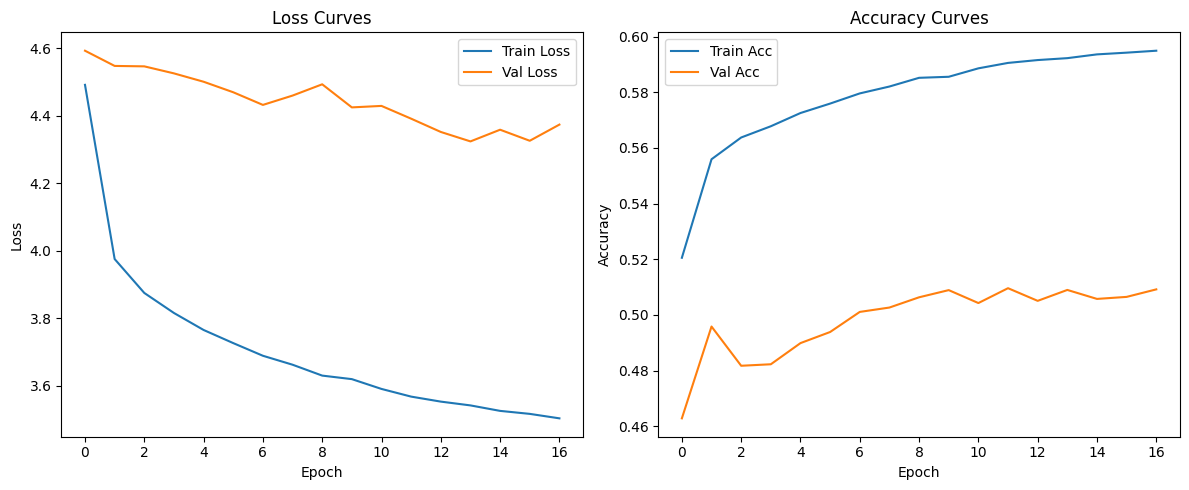

Final Validation BLEU: 0.0469


In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.tight_layout()
plt.show()
#%%
# Compute BLEU only at the end for validation set
val_bleu = compute_bleu(model, val_loader, nl_vocab)
print(f"Final Validation BLEU: {val_bleu:.4f}")


In [6]:
best_config2 = {
    "lr": 0.0004,
    "tf_base": 0.5,          # lowered
    "tf_decay": 0.95,        # faster decay
    "dropout": 0.35,
    "hidden_dim": 256,
    "emb_dim": 256,
    "n_layers": 1
}
patience = 6                # Number of epochs to wait after no improvement
min_delta = 0.001           # Minimum improvement to be considered significant
best_val_loss = float('inf')
epochs_no_improve = 0
encoder = Encoder(len(eng_vocab), emb_dim=best_config2['emb_dim'], hidden_dim=best_config2['hidden_dim'], dropout=best_config2['dropout']).to(device)
decoder = Decoder(len(nl_vocab), emb_dim=best_config2['emb_dim'], hidden_dim=best_config2['hidden_dim'], dropout=best_config2['dropout']).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_config['lr'], weight_decay=1e-5)  # Added weight_decay
criterion = torch.nn.CrossEntropyLoss(ignore_index=0)

In [7]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []
for epoch in range(20):
    teacher_forcing_ratio = best_config2['tf_base'] * (best_config2['tf_decay'] ** epoch)

    train_loss, train_acc = train(
        model, train_loader, optimizer, criterion, epoch,
        teacher_forcing_ratio=teacher_forcing_ratio
    )

    val_loss, val_acc = evaluate(model, val_loader, criterion)


    print(f"Epoch {epoch+1} | TF Ratio: {teacher_forcing_ratio:.4f} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # --- EARLY STOPPING CHECK ---
    if best_val_loss - val_loss > min_delta:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Optional: Save best model
        torch.save(model.state_dict(), "best_model2.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch 1 | TF Ratio: 0.5000 | Train Loss: 3.4700, Train Acc: 0.6870 | Val Loss: 3.2843, Val Acc: 0.6746


Epoch 2 | TF Ratio: 0.4750 | Train Loss: 3.0902, Train Acc: 0.7066 | Val Loss: 3.2664, Val Acc: 0.6793


Epoch 3 | TF Ratio: 0.4512 | Train Loss: 3.0530, Train Acc: 0.7094 | Val Loss: 3.2750, Val Acc: 0.6874


Epoch 4 | TF Ratio: 0.4287 | Train Loss: 3.0309, Train Acc: 0.7106 | Val Loss: 3.2452, Val Acc: 0.6877


Epoch 5 | TF Ratio: 0.4073 | Train Loss: 3.0138, Train Acc: 0.7117 | Val Loss: 3.2086, Val Acc: 0.6880


...

Epoch 16 | TF Ratio: 0.2316 | Train Loss: 2.9445, Train Acc: 0.7127 | Val Loss: 3.1140, Val Acc: 0.6939


Epoch 17 | TF Ratio: 0.2201 | Train Loss: 2.9424, Train Acc: 0.7121 | Val Loss: 3.1059, Val Acc: 0.6942


Epoch 18 | TF Ratio: 0.2091 | Train Loss: 2.9381, Train Acc: 0.7119 | Val Loss: 3.0995, Val Acc: 0.6947


Epoch 19 | TF Ratio: 0.1986 | Train Loss: 2.9353, Train Acc: 0.7115 | Val Loss: 3.0941, Val Acc: 0.6944


Epoch 20 | TF Ratio: 0.1887 | Train Loss: 2.9340, Train Acc: 0.7109 | Val Loss: 3.0951, Val Acc: 0.6946


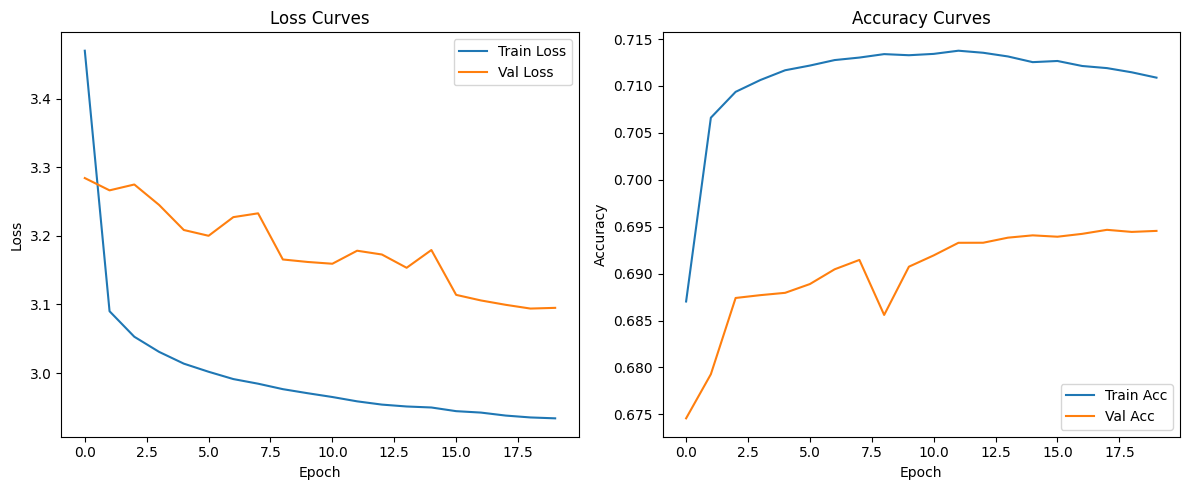

Final Validation BLEU: 0.0265


In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.tight_layout()
plt.show()
#%%
# Compute BLEU only at the end for validation set
val_bleu = compute_bleu(model, val_loader, nl_vocab)
print(f"Final Validation BLEU: {val_bleu:.4f}")